# Simulation comparison

This notebook runs three different simulators, Copula, TVAE, and per-protein, 
for the three experimental datasets included in this repository: CRC, MEL, and PDAC.

Note the PDAC experiments includes two acquisition (DIA+MRM) resulting in four 
simulations.

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from protmapper import uniprot_client
from indra.databases import hgnc_client

from MSquantSim.simulate import simulate_using_copula, simulate_using_tvae, \
    simulate_using_per_protein
from MSquantSim.downstreamanalysis import run_random_forest
from causomic.graph_construction.utils import get_neighbor_network
from causomic.graph_construction.indra_queries import get_ids, format_query_results
from sklearn.impute import KNNImputer

import warnings
warnings.filterwarnings('ignore')

import os
from indra_cogex.client import Neo4jClient

client = Neo4jClient(url=os.getenv("API_URL"), 
                        auth=(os.getenv("USER"), 
                            os.getenv("PASSWORD"))
                    )

/Users/kohler.d/miniconda3/envs/MSquantSim_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO: [2025-12-17 09:45:25] indra_cogex.client.neo4j_client - Connected to neo4j graph at bolt://indra-cogex-lb-b954b684556c373c.elb.us-east-1.amazonaws.com:7687


In [2]:
def hgnc_converter(id, mnemonic_id=False):
    if mnemonic_id:
        uniprot_id = uniprot_client.get_id_from_mnemonic(id)
    else:
        uniprot_id = id
    hgnc_id = uniprot_client.get_hgnc_id(uniprot_id)
    hgnc_name = hgnc_client.get_hgnc_name(hgnc_id)
    return hgnc_name

# CRC

## Load and prepare data

In [4]:
crc_input = pd.read_csv('../../data/CRC_data/CRC_training_protein_level_data.csv')
crc_validation_input = pd.read_csv('../../data/CRC_data/CRC_validation_protein_level_data.csv')
crc_input.head()

,Run,A1AG2,AFM,AHSG,ANT3,AOC3,APOB,ATRN,BTD,C20orf3,...,SERPINA1,SERPINA3,SERPINA6,SERPINA7,THBS1,TIMP1,VTN,VWF,Condition,BioReplicate
0,CRC_P1A10,14.238157,16.103019,19.951792,17.207936,10.032169,15.544774,14.383388,16.283071,10.667779,...,18.061091,14.218036,15.796849,13.581848,13.995686,11.578754,12.081352,10.661031,CRC,CRC_P1A10
1,CRC_P1A2,15.024111,16.020714,19.715919,17.297900,9.034144,15.131883,13.981723,16.249189,10.703279,...,17.610188,14.832327,15.815397,13.138445,13.707714,11.960974,12.838407,10.778432,CRC,CRC_P1A2
2,CRC_P1A4,15.631364,16.143800,19.710849,17.596254,10.381880,15.955302,14.635355,16.499158,11.183873,...,18.539972,15.308726,16.401770,13.742330,15.636962,12.155842,12.313155,11.185271,CRC,CRC_P1A4
3,CRC_P1A6,15.401365,16.276415,19.704377,17.422504,9.502960,15.714932,14.060700,16.277732,9.972982,...,17.401414,14.254241,16.310491,13.936894,15.517268,12.379265,10.679166,10.887855,CRC,CRC_P1A6
4,CRC_P1B12,16.003158,16.958207,20.420334,17.988199,9.648502,16.247330,14.203595,16.541422,12.581556,...,17.448008,16.231911,16.485833,14.167134,15.129106,12.169116,14.506106,11.254175,CRC,CRC_P1B12


In [8]:
len(crc_input.columns)

70

In [45]:
# Split into health and disease
crc_healthy = crc_input[crc_input['Condition'] == 'Healthy'].drop(columns=['Condition', 'Run', 'BioReplicate'])
crc_disease = crc_input[crc_input['Condition'] == 'CRC'].drop(columns=['Condition', 'Run', 'BioReplicate'])

## Copula

### Single simulation

In [46]:
copula_sim_healthy = simulate_using_copula(
    crc_healthy, num_simulations=1, 
    samples_per_simulation=len(crc_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

copula_sim_disease = simulate_using_copula(
    crc_disease, num_simulations=1, 
    samples_per_simulation=len(crc_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

INFO: [2025-12-16 12:34:56] copulas.multivariate.gaussian - Fitting GaussianMultivariate()
INFO: [2025-12-16 12:35:04] copulas.multivariate.gaussian - Fitting GaussianMultivariate()


### Multiple simulations

In [ ]:
n_sims = 10

copula_sim_healthy = simulate_using_copula(
    crc_healthy, num_simulations=n_sims, 
    samples_per_simulation=len(crc_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

copula_sim_disease = simulate_using_copula(
    crc_disease, num_simulations=n_sims, 
    samples_per_simulation=len(crc_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

## TVAE

### Single simulation

In [ ]:
tvae_sim_healthy = simulate_using_tvae(
    crc_healthy, None, num_simulations=1,
    samples_per_simulation=len(crc_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

tvae_sim_disease = simulate_using_tvae(
    crc_disease, None, num_simulations=1,
    samples_per_simulation=len(crc_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

### Multiple simulations

In [ ]:
n_sims = 10

tvae_sim_healthy = simulate_using_tvae(
    crc_healthy, None, num_simulations=n_sims,
    samples_per_simulation=len(crc_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

tvae_sim_disease = simulate_using_tvae(
    crc_disease, None, num_simulations=n_sims,
    samples_per_simulation=len(crc_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

## Per-protein

### Single simulation

In [ ]:
pprotein_sim_healthy = simulate_using_per_protein(
    crc_healthy, num_simulations=1,
    samples_per_simulation=len(crc_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

pprotein_sim_disease = simulate_using_per_protein(
    crc_disease, num_simulations=1,
    samples_per_simulation=len(crc_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

### Multiple simulations

In [ ]:
n_sims = 10

pprotein_sim_healthy = simulate_using_per_protein(
    crc_healthy, num_simulations=n_sims,
    samples_per_simulation=len(crc_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

pprotein_sim_disease = simulate_using_per_protein(
    crc_disease, num_simulations=n_sims,
    samples_per_simulation=len(crc_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

# MEL

## Load and prepare data

In [28]:
mel_input = pd.read_csv('../../data/MEL_data/MEL_protein_level_data.csv')
mel_input = mel_input.loc[:, ~mel_input.columns.str.contains(';', na=False)]
mel_input.columns = [col.split('|')[1] if '|' in col else col for col in mel_input.columns]
mel_input = mel_input.drop(columns=["Run", "Channel"])

mel_input.columns = [hgnc_converter(i, mnemonic_id=False) if i != "Condition" \
    else "Condition" for i in mel_input.columns]
mel_input.head()

,Condition,ARHGAP10,EFCAB5,FAM186A,ZBTB42,NACA,CROCC2,ACOT7,MYO1C,SNAP23,...,TC2N,MED17,ARGLU1,BTG4,NAGK,SHROOM4,UTP18,ABHD8,BABAM1,HDAC11
0,u,10.449841,11.267802,10.620656,12.056047,10.616000,8.971095,7.622955,9.967160,10.002026,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,u,9.988900,9.341027,10.188457,11.560510,10.587988,9.142974,7.911131,9.644867,9.406374,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,m,9.731853,8.977844,10.933736,13.109581,10.729755,10.703360,8.243595,10.009776,9.323197,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,m,10.151383,9.964322,10.468290,13.302292,10.721968,NaN,8.699114,9.753093,10.364373,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,m,10.675715,10.823538,11.139793,12.791292,10.218707,7.363879,7.709675,9.950416,10.489982,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Filter data using missing values and INDRA network

In [29]:
# Count missing values per column
missing_counts = mel_input.isna().sum()
missing_percentages = (missing_counts / len(mel_input))

print(f"Columns with missing values: {(missing_counts > 0).sum()}")
print(f"Total missing values: {missing_counts.sum()}")

# Remove columns with more than 50% missing values
threshold = 0.5
cols_to_keep = missing_percentages[missing_percentages <= threshold].index
mel_input = mel_input[cols_to_keep]

print(f"\nColumns after filtering: {len(mel_input.columns)}")
print(f"Columns removed: {len(missing_percentages) - len(cols_to_keep)}")

Columns with missing values: 3139
Total missing values: 1218425

Columns after filtering: 1148
Columns removed: 1992


In [31]:
len(mel_input.columns) - 1

1147

In [29]:
test_network = format_query_results(get_neighbor_network(
    nodes=query_ids,
    client=client,
    relation=["IncreaseAmount", "DecreaseAmount"],
    upstream=True,
    downstream=True,
    minimum_evidence_count=5,
    filter_all_nodes=True))

filtered = test_network.loc[:, ["source", "target"]].drop_duplicates()

G = nx.DiGraph()
for i in range(len(filtered)):
    G.add_edge(filtered.iloc[i]["source"], filtered.iloc[i]["target"])

components = list(nx.weakly_connected_components(G))
max_component = max(components, key=len)
print(f"Largest connected component size: {len(max_component)} nodes")

cols = [c for c in mel_input.columns if (c == 'Condition' or c in max_component)]
mel_input = mel_input.loc[:, cols]

Largest connected component size: 124 nodes


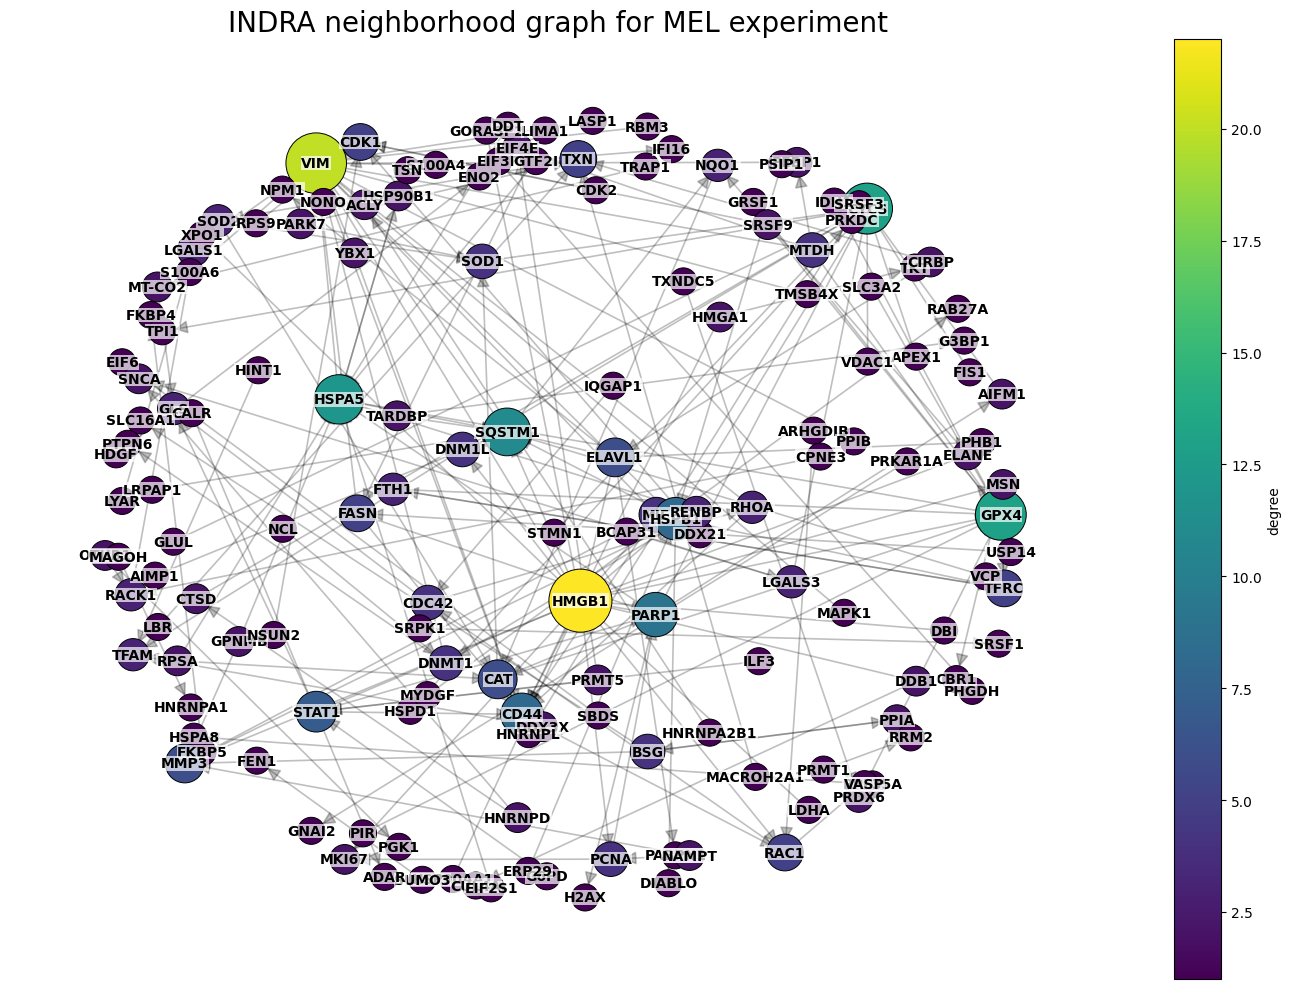

In [30]:
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42, k=.8)  # slightly more spacing
deg = dict(G.degree())
# Bigger nodes overall
node_sizes = [300 + deg[n] * 80 for n in G.nodes()]
node_colors = [deg[n] for n in G.nodes()]
nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.25,
    arrowsize=20,
    width=1.2
)
nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap="viridis",
    edgecolors="black",
    linewidths=0.7
)
nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_weight="bold",
    bbox=dict(
        facecolor="white",
        edgecolor="none",
        alpha=0.7,
        pad=0.2
    )
)
plt.colorbar(nodes, label="degree")
plt.title("INDRA neighborhood graph for MEL experiment", fontsize=20)
plt.axis("off")
plt.tight_layout()
plt.show()

### Impute missing values

In [ ]:
# Keep original column order
orig_cols = mel_input.columns.tolist()

# Split numeric and non-numeric columns
numeric_cols = [c for c in orig_cols if pd.api.types.is_numeric_dtype(mel_input[c])]
non_numeric_cols = [c for c in orig_cols if c not in numeric_cols]

# Report missing values before imputation
print("Missing values before imputation (numeric cols):")
print(mel_input[numeric_cols].isna().sum().sum())

# KNN imputation
imputer = KNNImputer(n_neighbors=5, weights="uniform")
imputed_array = imputer.fit_transform(mel_input[numeric_cols])

# Build imputed DataFrame and restore original column order
imputed_numeric = pd.DataFrame(imputed_array, columns=numeric_cols, index=mel_input.index)
mel_input = pd.concat([mel_input[non_numeric_cols], imputed_numeric], axis=1)[orig_cols]

# Report missing values after imputation
print("\nMissing values after imputation (numeric cols):")
print(mel_input[numeric_cols].isna().sum().sum())

Missing values before imputation (numeric cols):
10496

Missing values after imputation (numeric cols):
0


In [32]:
# Split into health and disease
mel_healthy = mel_input[mel_input['Condition'] == "u"].drop(columns=['Condition'])
mel_disease = mel_input[mel_input['Condition'] == "m"].drop(columns=['Condition'])

In [34]:
mel_healthy.head()

,DDX3X,PIR,PRMT5,XPO1,CPNE3,MACROH2A1,PSIP1,IDH1,GLS,AIFM1,...,DNM1L,CDK1,GLUL,GPX4,USP14,RBM3,LASP1,DIABLO,LIMA1,GRSF1
0,9.099064,9.783696,10.502268,8.909095,10.115059,8.794337,8.523487,9.653396,8.810845,8.511018,...,8.469644,10.089932,10.645780,8.531974,9.347187,9.837232,10.311711,14.183632,11.588486,9.072424
1,10.010491,9.360264,9.751682,9.207139,10.093208,8.010631,9.221851,9.460861,8.871287,7.944545,...,8.323297,9.904290,10.687988,8.902241,8.817976,10.158084,10.412729,13.672828,11.456852,8.859214
8,9.346990,10.553571,10.360573,9.533039,10.169222,9.798709,9.563130,10.585194,7.939550,8.677462,...,8.031204,9.789540,10.857560,9.323271,9.299829,10.869589,10.121980,14.148033,11.839861,9.338212
9,9.567772,10.928405,10.003267,9.198541,9.921314,9.417135,8.818566,9.760575,9.492402,8.364762,...,8.607676,9.915853,10.662570,9.095007,9.020460,10.758311,10.514252,13.700885,11.576995,9.157730
10,9.256519,9.030232,9.644022,8.593391,8.948854,8.499681,8.367662,9.819181,8.866103,8.518947,...,7.968344,9.525700,10.628336,8.519930,9.238446,10.030480,10.012083,13.867745,11.717314,9.357831


## Copula

### Single simulation

In [35]:
copula_sim_mel_healthy_single = simulate_using_copula(
    mel_healthy, num_simulations=1, 
    samples_per_simulation=len(mel_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

copula_sim_mel_disease_single = simulate_using_copula(
    mel_disease, num_simulations=1, 
    samples_per_simulation=len(mel_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

INFO: [2025-12-16 10:10:15] copulas.multivariate.gaussian - Fitting GaussianMultivariate()
INFO: [2025-12-16 10:10:36] copulas.multivariate.gaussian - Fitting GaussianMultivariate()


### Multiple simulations

In [ ]:
n_sims = 10

copula_sim_mel_healthy_multi = simulate_using_copula(
    mel_healthy, num_simulations=n_sims, 
    samples_per_simulation=len(mel_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

copula_sim_mel_disease_multi = simulate_using_copula(
    mel_disease, num_simulations=n_sims, 
    samples_per_simulation=len(mel_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=100
)

100%|██████████| 10/10 [00:20<00:00,  2.08s/it]10 [00:00<?, ?it/s]






100%|██████████| 10/10 [00:16<00:00,  1.63s/it]


## TVAE

### Single simulation

In [37]:
tvae_sim_mel_healthy_single = simulate_using_tvae(
    mel_healthy, None, num_simulations=1,
    samples_per_simulation=len(mel_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

tvae_sim_mel_disease_single = simulate_using_tvae(
    mel_disease, None, num_simulations=1,
    samples_per_simulation=len(mel_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

INFO: [2025-12-16 10:12:27] sdv.metadata.single_table - Detected metadata:
INFO: [2025-12-16 10:12:27] sdv.metadata.single_table - {
    "METADATA_SPEC_VERSION": "SINGLE_TABLE_V1",
    "columns": {
        "DDX3X": {
            "sdtype": "numerical"
        },
        "PIR": {
            "sdtype": "numerical"
        },
        "PRMT5": {
            "sdtype": "numerical"
        },
        "XPO1": {
            "sdtype": "numerical"
        },
        "CPNE3": {
            "sdtype": "numerical"
        },
        "MACROH2A1": {
            "sdtype": "numerical"
        },
        "PSIP1": {
            "sdtype": "numerical"
        },
        "IDH1": {
            "sdtype": "numerical"
        },
        "GLS": {
            "sdtype": "numerical"
        },
        "AIFM1": {
            "sdtype": "numerical"
        },
        "LDHA": {
            "sdtype": "numerical"
        },
        "MT-CO2": {
            "sdtype": "numerical"
        },
        "SOD1": {
            "sdtyp

### Multiple simulations

In [38]:
n_sims = 10

tvae_sim_mel_healthy_multi = simulate_using_tvae(
    mel_healthy, None, num_simulations=n_sims,
    samples_per_simulation=len(mel_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

tvae_sim_mel_disease_multi = simulate_using_tvae(
    mel_disease, None, num_simulations=n_sims,
    samples_per_simulation=len(mel_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

INFO: [2025-12-16 10:13:35] sdv.metadata.single_table - Detected metadata:
INFO: [2025-12-16 10:13:35] sdv.metadata.single_table - {
    "METADATA_SPEC_VERSION": "SINGLE_TABLE_V1",
    "columns": {
        "DDX3X": {
            "sdtype": "numerical"
        },
        "PIR": {
            "sdtype": "numerical"
        },
        "PRMT5": {
            "sdtype": "numerical"
        },
        "XPO1": {
            "sdtype": "numerical"
        },
        "CPNE3": {
            "sdtype": "numerical"
        },
        "MACROH2A1": {
            "sdtype": "numerical"
        },
        "PSIP1": {
            "sdtype": "numerical"
        },
        "IDH1": {
            "sdtype": "numerical"
        },
        "GLS": {
            "sdtype": "numerical"
        },
        "AIFM1": {
            "sdtype": "numerical"
        },
        "LDHA": {
            "sdtype": "numerical"
        },
        "MT-CO2": {
            "sdtype": "numerical"
        },
        "SOD1": {
            "sdtyp

## Per-protein

### Single simulation

In [39]:
pprotein_sim_mel_healthy_single = simulate_using_per_protein(
    mel_healthy, num_simulations=1,
    samples_per_simulation=len(mel_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

pprotein_sim_mel_disease_single = simulate_using_per_protein(
    mel_disease, num_simulations=1,
    samples_per_simulation=len(mel_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

### Multiple simulations

In [40]:
n_sims = 10

pprotein_sim_mel_healthy_multi = simulate_using_per_protein(
    mel_healthy, num_simulations=n_sims,
    samples_per_simulation=len(mel_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

pprotein_sim_mel_disease_multi = simulate_using_per_protein(
    mel_disease, num_simulations=n_sims,
    samples_per_simulation=len(mel_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)






100%|██████████| 10/10 [00:00<00:00, 145.54it/s]











100%|██████████| 10/10 [00:01<00:00,  5.21it/s]


# PDAC - DIA

## Load and prepare data

In [22]:
pdac_dia_input = pd.read_csv('../../data/PDAC_data/dia/PDAC_DIA_protein_level_data.csv')
pdac_dia_input = pdac_dia_input.loc[:, ~pdac_dia_input.columns.str.contains(';', na=False)]

keep = ["originalRUN", "GROUP"]

# Convert UniProt to HGNC
orig_cols = list(pdac_dia_input.columns)
new_cols = []
dropped = []

for col in orig_cols:
    if col in keep:
        new_cols.append(col)
    else:
        try:
            new_name = hgnc_converter(col, mnemonic_id=True)
            new_cols.append(new_name)
        except Exception:
            dropped.append(col)

if dropped:
    pdac_dia_input = pdac_dia_input.drop(columns=dropped)

pdac_dia_input.columns = new_cols
pdac_dia_input = pdac_dia_input.drop(columns=[None])
pdac_dia_input.head()

,originalRUN,GROUP,YWHAZ,ORM1,ORM2,SERPINA1,A1BG,SERPINF2,LRG1,A2M,...,FERMT3,VASN,VCAM1,FLT4,VNN1,GC,VTN,VWF,AZGP1,SERPINA10
0,BRI_EXPLORIS-02_DIA_2023-02-13_Pancrea_serum_G...,Cancer,13.720977,22.678027,19.012034,25.865981,21.171464,20.256547,18.750093,24.802330,...,NaN,17.003341,14.227452,14.255811,13.605172,21.543858,21.464663,17.910064,18.854173,17.350070
1,BRI_EXPLORIS-02_DIA_2023-02-13_Pancrea_serum_G...,Cancer,12.942413,22.596331,19.442896,25.342580,20.971118,19.994507,17.474589,24.712653,...,12.166275,16.194895,11.833424,13.801040,13.834975,21.501168,21.330001,17.219232,18.547639,17.284836
2,BRI_EXPLORIS-02_DIA_2023-02-13_Pancrea_serum_G...,Cancer,15.342044,22.437251,18.727350,25.708211,20.880269,19.933185,17.862387,26.217061,...,13.338471,17.033332,13.964083,14.630975,12.193326,21.759486,21.277845,18.390726,17.776644,16.849922
3,BRI_EXPLORIS-02_DIA_2023-02-15_Pancrea_serum_G...,Cancer,14.567717,22.761760,19.171237,25.561015,21.124192,20.016456,17.906203,25.265648,...,12.613046,16.726915,14.351752,14.475815,15.126831,21.964008,21.543723,17.460366,17.961643,17.327577
4,BRI_EXPLORIS-02_DIA_2023-02-15_Pancrea_serum_G...,Cancer,13.897988,22.785164,19.162129,25.408356,21.071123,19.609220,18.801775,24.690819,...,12.440502,16.110067,13.571316,15.178826,14.913476,21.516709,21.250352,18.041408,17.587058,16.979710


In [23]:
# Count missing values per column
missing_counts = pdac_dia_input.isna().sum()
missing_percentages = (missing_counts / len(pdac_dia_input))

print(f"Columns with missing values: {(missing_counts > 0).sum()}")
print(f"Total missing values: {missing_counts.sum()}")

# Remove columns with more than 50% missing values
threshold = 0.5
cols_to_keep = missing_percentages[missing_percentages <= threshold].index
pdac_dia_input = pdac_dia_input[cols_to_keep]

print(f"\nColumns after filtering: {len(pdac_dia_input.columns)}")
print(f"Columns removed: {len(missing_percentages) - len(cols_to_keep)}")

Columns with missing values: 365
Total missing values: 6745

Columns after filtering: 399
Columns removed: 73


In [24]:
len(pdac_dia_input.columns ) - 2

397

In [15]:
# Keep original column order
orig_cols = pdac_dia_input.columns.tolist()

# Split numeric and non-numeric columns
numeric_cols = [c for c in orig_cols if pd.api.types.is_numeric_dtype(pdac_dia_input[c])]
non_numeric_cols = [c for c in orig_cols if c not in numeric_cols]

# Report missing values before imputation
print("Missing values before imputation (numeric cols):")
print(pdac_dia_input[numeric_cols].isna().sum().sum())

# KNN imputation
imputer = KNNImputer(n_neighbors=5, weights="uniform")
imputed_array = imputer.fit_transform(pdac_dia_input[numeric_cols])

# Build imputed DataFrame and restore original column order
imputed_numeric = pd.DataFrame(imputed_array, columns=numeric_cols, index=pdac_dia_input.index)
pdac_dia_input = pd.concat([pdac_dia_input[non_numeric_cols], imputed_numeric], axis=1)[orig_cols]

# Report missing values after imputation
print("\nMissing values after imputation (numeric cols):")
print(pdac_dia_input[numeric_cols].isna().sum().sum())

Missing values before imputation (numeric cols):
2060

Missing values after imputation (numeric cols):
0


In [16]:
# Split into health and disease
pdac_dia_input_healthy = pdac_dia_input[pdac_dia_input['GROUP'] == 'Normal'].drop(columns=['originalRUN', 'GROUP'])
pdac_dia_input_disease = pdac_dia_input[pdac_dia_input['GROUP'] == 'Cancer'].drop(columns=['originalRUN', 'GROUP'])

## Copula

### Single simulation

In [ ]:
copula_sim_pdac_healthy_single = simulate_using_copula(
    pdac_dia_input_healthy, num_simulations=1, 
    samples_per_simulation=len(pdac_dia_input_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

copula_sim_pdac_disease_single = simulate_using_copula(
    pdac_dia_input_disease, num_simulations=1, 
    samples_per_simulation=len(pdac_dia_input_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

INFO: [2025-12-17 09:47:46] copulas.multivariate.gaussian - Fitting GaussianMultivariate()
INFO: [2025-12-17 09:48:34] copulas.multivariate.gaussian - Fitting GaussianMultivariate()


### Multiple simulations

In [18]:
n_sims = 10

copula_sim_pdac_healthy_multi = simulate_using_copula(
    pdac_dia_input_healthy, num_simulations=n_sims, 
    samples_per_simulation=len(pdac_dia_input_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=100
)

copula_sim_pdac_disease_multi = simulate_using_copula(
    pdac_dia_input_disease, num_simulations=n_sims, 
    samples_per_simulation=len(pdac_dia_input_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=100
)

100%|██████████| 10/10 [02:03<00:00, 12.33s/it]10 [00:00<?, ?it/s]









100%|██████████| 10/10 [01:43<00:00, 10.33s/it]


## TVAE

### Single simulation

In [ ]:
tvae_sim_pdac_healthy_single = simulate_using_tvae(
    pdac_dia_input_healthy, None, num_simulations=1,
    samples_per_simulation=len(pdac_dia_input_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

tvae_sim_pdac_disease_single = simulate_using_tvae(
    pdac_dia_input_disease, None, num_simulations=1,
    samples_per_simulation=len(pdac_dia_input_disease),
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

### Multiple simulations

In [ ]:
tvae_sim_pdac_healthy_multi = simulate_using_tvae(
    pdac_dia_input_healthy, None, num_simulations=10,
    samples_per_simulation=len(pdac_dia_input_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

tvae_sim_pdac_disease_multi = simulate_using_tvae(
    pdac_dia_input_disease, None, num_simulations=10,
    samples_per_simulation=len(pdac_dia_input_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

## Per-protein

### Single simulation

In [ ]:
pprotein_sim_pdac_healthy_single = simulate_using_per_protein(
    pdac_dia_input_healthy, num_simulations=1,
    samples_per_simulation=len(pdac_dia_input_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

pprotein_sim_pdac_disease_single = simulate_using_per_protein(
    pdac_dia_input_disease, num_simulations=1,
    samples_per_simulation=len(pdac_dia_input_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

### Multiple simulations

In [ ]:
pprotein_sim_pdac_healthy_multi = simulate_using_per_protein(
    pdac_dia_input_healthy, num_simulations=10,
    samples_per_simulation=len(pdac_dia_input_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

pprotein_sim_pdac_disease_multi = simulate_using_per_protein(
    pdac_dia_input_disease, num_simulations=10,
    samples_per_simulation=len(pdac_dia_input_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

# PDAC - MRM

## Load and prepare data

In [4]:
pdac_mrm_input = pd.read_csv('../../data/PDAC_data/mrm/PDAC_MRM_protein_level_data.csv')
pdac_mrm_input.head()

,originalRUN,GROUP,ANPEP,APOA4,APOC3,C9,CRP,HGFAC,IGFBP2,ITIH3,LRG1,ORM1,PFN1,PIGR,PON3,SERPINA3,VWF
0,PC_092,Cancer,17.609804,22.932694,20.844543,21.868888,12.809162,18.129036,16.656216,21.327547,14.882559,22.540963,17.451308,19.184593,14.799060,23.054676,16.719290
1,PC_168,Cancer,15.307967,24.747555,23.052404,21.951272,13.274623,19.900789,15.570384,20.610561,13.878547,23.384084,17.845162,18.091750,15.604541,23.288847,16.804773
2,PC_180,Cancer,14.824129,23.780698,21.368211,21.431627,13.470326,19.496448,13.453160,21.455086,14.406445,22.486922,18.258667,16.550491,15.285278,23.093575,16.463111
3,PC_184,Cancer,15.428902,23.071761,21.480899,21.051913,13.159770,19.561567,13.698600,20.528751,14.884947,22.319877,18.209270,16.422534,15.417537,23.035198,15.606018
4,PC_192,Cancer,15.043882,23.876208,20.985391,22.371628,14.429354,19.278232,16.264604,21.417230,13.803319,23.328512,18.220354,16.999240,15.367538,23.089819,16.749216


In [46]:
from sklearn.impute import KNNImputer
import pandas as pd

# Keep original column order
orig_cols = pdac_mrm_input.columns.tolist()

# Split numeric and non-numeric columns (keep non-numeric like 'Sample type' intact)
numeric_cols = [c for c in orig_cols if pd.api.types.is_numeric_dtype(pdac_mrm_input[c])]
non_numeric_cols = [c for c in orig_cols if c not in numeric_cols]

# Report missing values before imputation
print("Missing values before imputation (numeric cols):")
print(pdac_mrm_input[numeric_cols].isna().sum())

# KNN imputation
imputer = KNNImputer(n_neighbors=5, weights="uniform")
imputed_array = imputer.fit_transform(pdac_mrm_input[numeric_cols])

# Build imputed DataFrame and restore original column order
imputed_numeric = pd.DataFrame(imputed_array, columns=numeric_cols, index=pdac_mrm_input.index)
pdac_mrm_input = pd.concat([pdac_mrm_input[non_numeric_cols], imputed_numeric], axis=1)[orig_cols]

# Report missing values after imputation
print("\nMissing values after imputation (numeric cols):")
print(pdac_mrm_input[numeric_cols].isna().sum())

Missing values before imputation (numeric cols):
ANPEP        0
APOA4        0
APOC3        0
C9           0
CRP         48
HGFAC        0
IGFBP2       9
ITIH3        0
LRG1         3
ORM1         0
PFN1         0
PIGR         0
PON3         0
SERPINA3     0
VWF          0
dtype: int64

Missing values after imputation (numeric cols):
ANPEP       0
APOA4       0
APOC3       0
C9          0
CRP         0
HGFAC       0
IGFBP2      0
ITIH3       0
LRG1        0
ORM1        0
PFN1        0
PIGR        0
PON3        0
SERPINA3    0
VWF         0
dtype: int64


In [49]:
pdac_mrm_input

,originalRUN,GROUP,ANPEP,APOA4,APOC3,C9,CRP,HGFAC,IGFBP2,ITIH3,LRG1,ORM1,PFN1,PIGR,PON3,SERPINA3,VWF
0,PC_092,Cancer,17.609804,22.932694,20.844543,21.868888,12.809162,18.129036,16.656216,21.327547,14.882559,22.540963,17.451308,19.184593,14.799060,23.054676,16.719290
1,PC_168,Cancer,15.307967,24.747555,23.052404,21.951272,13.274623,19.900789,15.570384,20.610561,13.878547,23.384084,17.845162,18.091750,15.604541,23.288847,16.804773
2,PC_180,Cancer,14.824129,23.780698,21.368211,21.431627,13.470326,19.496448,13.453160,21.455086,14.406445,22.486922,18.258667,16.550491,15.285278,23.093575,16.463111
3,PC_184,Cancer,15.428902,23.071761,21.480899,21.051913,13.159770,19.561567,13.698600,20.528751,14.884947,22.319877,18.209270,16.422534,15.417537,23.035198,15.606018
4,PC_192,Cancer,15.043882,23.876208,20.985391,22.371628,14.429354,19.278232,16.264604,21.417230,13.803319,23.328512,18.220354,16.999240,15.367538,23.089819,16.749216
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351,BS287,Normal,15.497739,23.636329,21.113323,21.656681,12.280433,19.897297,12.383467,21.557902,14.527049,22.497821,18.047401,17.628380,15.727640,23.278349,16.119177
352,BS288,Normal,15.434206,23.926478,20.976857,21.528846,13.721534,19.342086,14.573158,21.335434,13.487246,22.674171,18.177128,16.234072,15.522727,23.200475,16.323766
353,BS289,Normal,14.799727,24.203816,22.003839,21.166519,13.651551,19.778654,14.631556,21.088958,15.313743,23.275820,18.390483,16.484504,15.586692,23.179837,16.205118
354,BS293,Normal,15.089545,23.294121,21.569555,21.258569,12.838128,18.949297,14.780341,20.369386,13.933959,21.800915,18.158760,16.185769,15.469396,22.811558,15.866522


In [50]:
# Split into health and disease
pdac_mrm_input_healthy = pdac_mrm_input[pdac_mrm_input['GROUP'] == "Normal"].drop(columns=['originalRUN', 'GROUP'])
pdac_mrm_input_disease = pdac_mrm_input[pdac_mrm_input['GROUP'] == "Cancer"].drop(columns=['originalRUN', 'GROUP'])

## Copula

### Single simulation

In [51]:
copula_sim_pdac_mrm_healthy_single = simulate_using_copula(
    pdac_mrm_input_healthy, num_simulations=1, 
    samples_per_simulation=len(pdac_mrm_input_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

copula_sim_pdac_mrm_disease_single = simulate_using_copula(
    pdac_mrm_input_disease, num_simulations=1, 
    samples_per_simulation=len(pdac_mrm_input_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

INFO: [2025-12-16 13:11:15] copulas.multivariate.gaussian - Fitting GaussianMultivariate()
INFO: [2025-12-16 13:11:18] copulas.multivariate.gaussian - Fitting GaussianMultivariate()


### Multiple simulations

In [ ]:
copula_sim_pdac_mrm_healthy_multi = simulate_using_copula(
    pdac_mrm_input_healthy, num_simulations=10, 
    samples_per_simulation=len(pdac_mrm_input_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

copula_sim_pdac_mrm_disease_multi = simulate_using_copula(
    pdac_mrm_input_disease, num_simulations=10, 
    samples_per_simulation=len(pdac_mrm_input_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=100
)


## TVAE

### Single simulation

In [ ]:
tvae_sim_pdac_mrm_healthy_single = simulate_using_tvae(
    pdac_mrm_input_healthy, None, num_simulations=1,
    samples_per_simulation=len(pdac_mrm_input_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

tvae_sim_pdac_mrm_disease_single = simulate_using_tvae(
    pdac_mrm_input_disease, None, num_simulations=1,
    samples_per_simulation=len(pdac_mrm_input_disease),
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

### Multiple simulations

In [ ]:
tvae_sim_pdac_mrm_healthy_multi = simulate_using_tvae(
    pdac_mrm_input_healthy, None, num_simulations=10,
    samples_per_simulation=len(pdac_mrm_input_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

tvae_sim_pdac_mrm_disease_multi = simulate_using_tvae(
    pdac_mrm_input_disease, None, num_simulations=10,
    samples_per_simulation=len(pdac_mrm_input_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

## Per-protein

### Single simulation

In [ ]:
pprotein_sim_pdac_mrm_healthy_single = simulate_using_per_protein(
    pdac_mrm_input_healthy, num_simulations=1,
    samples_per_simulation=len(pdac_mrm_input_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

pprotein_sim_pdac_mrm_disease_single = simulate_using_per_protein(
    pdac_mrm_input_disease, num_simulations=1,
    samples_per_simulation=len(pdac_mrm_input_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

### Multiple simulations

In [ ]:
pprotein_sim_pdac_mrm_healthy_multi = simulate_using_per_protein(
    pdac_mrm_input_healthy, num_simulations=10,
    samples_per_simulation=len(pdac_mrm_input_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

pprotein_sim_pdac_mrm_disease_multi = simulate_using_per_protein(
    pdac_mrm_input_disease, num_simulations=10,
    samples_per_simulation=len(pdac_mrm_input_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

# Random Forest

## CRC

In [ ]:
run_random_forest(crc_input, "Condition", len(crc_input), True, n_runs=10)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score


In [ ]:
X = crc_input.drop(columns=['Condition'])
y = crc_input['Condition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2)

In [ ]:
param_grid = {
    "n_estimators": [200, 500, 1000],
    "max_depth": [None, 10, 20, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.5],
    "class_weight": [None, "balanced"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    RandomForestClassifier(),
    param_distributions=param_grid,
    cv=cv,
    n_iter=30,
    scoring="accuracy",
    n_jobs=-1
)

search.fit(X_train, y_train)

In [ ]:
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print("Test accuracy:", test_accuracy)

In [ ]:
y_prob = best_model.predict_proba(X_test)[:, 1]

## MEL

## PDAC - DIA

## PDAC - MRM